In [1]:
from transformers import AutoTokenizer

tokenizer_base = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B")
tokenizer_base.save_pretrained("Qwen2.5-7B")

('Qwen2.5-7B/tokenizer_config.json',
 'Qwen2.5-7B/special_tokens_map.json',
 'Qwen2.5-7B/vocab.json',
 'Qwen2.5-7B/merges.txt',
 'Qwen2.5-7B/added_tokens.json',
 'Qwen2.5-7B/tokenizer.json')

In [2]:
len(tokenizer_base)  # This will give you the size of the tokenizer vocabulary

151665

In [3]:
import json
tokenizer_json = json.load(open("./Qwen2.5-7B/tokenizer.json"))
vocab_base = tokenizer_json["model"]["vocab"]
merges_base = tokenizer_json["model"]["merges"]

In [4]:
def checkList(list_tokens, vocab_to_check):
    # print('++Checking list of tokens:', list_tokens)
    merged_tokens = list_tokens[:]
    longest_token = ""
    start_idx, end_idx = -1, -1
    
    for i in range(len(list_tokens)):
        for j in range(i + 1, len(list_tokens) + 1):
            candidate = "".join(list_tokens[i:j])
            if candidate in vocab_to_check:
                if len(candidate) > len(longest_token):
                    longest_token = candidate
                    start_idx, end_idx = i, j

    if longest_token:
        merged_tokens = list_tokens[:start_idx] + [longest_token] + list_tokens[end_idx:]

    # print('--Merged tokens:', merged_tokens)
    return merged_tokens

In [5]:
import os, glob
import pickle as pkl
import json
from collections import defaultdict

for fname in glob.glob("./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Vocab/*.txt"):
    
    print('***********Processing:',fname)
    
    vocab_to_merges = defaultdict(list)
    
    tokenizer_base = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B")
    
    tokenizer_json = json.load(open("./Qwen2.5-7B/tokenizer.json", 'r', encoding='utf-8'))
    vocab_base = tokenizer_json["model"]["vocab"]
    merges_base = tokenizer_json["model"]["merges"]
    
    words_to_add = open(fname,'r',encoding='utf-8').read().splitlines()
    words_to_add = sorted(words_to_add, key=lambda x: len(x))
    
    drop_words = []
    for idx,word in enumerate(words_to_add):
        if word in vocab_base:
            drop_words.append(idx)
    
    for idx in drop_words[::-1]: del words_to_add[idx]
    
    for word in words_to_add:
        
        split = tokenizer_base.tokenize(word if not word.startswith('Ġ') else ' '+word[1:])

        if len(split) == 1:
            continue
        
        if len(split) == 2: #pass
            vocab_to_merges[word] = [split[0],split[1]]
        
        if len(split) >= 3:
            new_split = checkList(split, vocab_to_merges)
            if len(new_split) == 2:
                vocab_to_merges[word] = [new_split[0],new_split[1]]
                continue
            
            new_word=new_split[0]
            for i in range(1,len(new_split)):
                left = new_word
                right = new_split[i]
                new_word += new_split[i]
                if new_word not in vocab_to_merges:
                    vocab_to_merges[new_word] = [left,right]
                
    
    idx = 0
    for key,val in vocab_to_merges.items():
        if key not in tokenizer_json["model"]["vocab"]:
            tokenizer_json["model"]["vocab"][key] = len(tokenizer_json["model"]["vocab"])
            tokenizer_json["model"]["merges"].append(val)

    dump_dir = f'./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Tokenizers/SupremeCourtCase_DomainSpecific_MEDVOC_Qwen2.5_{fname.split("/")[-1][:-4]}'
    tokenizer_base.save_pretrained(dump_dir)
    
    with open(dump_dir+'/tokenizer.json', 'w', encoding='utf-8') as f:
        json.dump(tokenizer_json, f)
    f.close()
    
    vocab_base_dump = json.load(open(dump_dir+'/vocab.json', 'r', encoding='utf-8'))
    idx = 0
    for key,val in vocab_to_merges.items():
        vocab_base_dump[key] = len(vocab_base_dump)
    
    with open(dump_dir+'/vocab.json', 'w', encoding='utf-8') as f:
        json.dump(vocab_base_dump, f)
    f.close()
    
    merge_base_dump = open(dump_dir+'/merges.txt', 'r', encoding='utf-8').read()
    for item in vocab_to_merges.values():
        merge_base_dump += '\n' + ' '.join(item)
    
    with open(dump_dir+'/merges.txt', 'w', encoding='utf-8') as f:
        f.write(merge_base_dump)
    f.close()

***********Processing: ./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Vocab/5.0_.txt
***********Processing: ./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Vocab/80.0_.txt
***********Processing: ./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Vocab/10.0_.txt
***********Processing: ./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Vocab/90.0_.txt
***********Processing: ./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Vocab/20.0_.txt
***********Processing: ./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Vocab/30.0_.txt
***********Processing: ./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Vocab/100.0_.txt
***********Processing: ./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Vocab/60.0_.txt
***********Processing: ./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Vocab/70.0_.txt
***********Processing: ./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen

In [ ]:
import regex as re
from collections import Counter
import pandas as pd
import glob

tokenizer_base = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B")
df = pd.read_csv('../CPT-DATA-DIR/CPT-Eval-SupremeCourtCase-SplitMoreThan1-Llama3.1.csv', encoding='utf-8')
        
df_dump = pd.DataFrame({'Word': df['Word'], 'Count': df['Count'], 'Splits': df['Word'].apply(lambda x: len(tokenizer_base.tokenize(x)))})
df_dump.to_csv('../CPT-DATA-DIR/CPT-Eval-SupremeCourtCase-SplitMoreThan1-Qwen2.5.csv', index=False)

In [6]:
import pandas as pd
from transformers import AutoTokenizer
from tqdm import tqdm


df = pd.read_csv('../../data/Legal_Val_OOV_Tokens.csv')

freq_ebm = df['Count'].to_list()
terms_EBM = df['Word'].to_list()
split_bart = df['Splits'].to_list()

sum_num = 0.
sum_den = 0.
for idx,term in enumerate(terms_EBM):
    sum_num += split_bart[idx]*freq_ebm[idx]
    sum_den += freq_ebm[idx]

old_score = sum_num/sum_den


import glob
from collections import defaultdict

dict_scores = defaultdict(lambda : defaultdict(dict))
for fname in tqdm(sorted(glob.glob('./VocabFiles/CPT-SupremeCourtCase/CPT-SupremeCourtCase-Qwen2.5_Tokenizers/*'), key=lambda x: int(float(x.split('_')[-2])))): 
    # print('***********Processing:',fname, fname.split('/')[-1].split('_')[1])
    try:
        domain_tok = AutoTokenizer.from_pretrained(fname)
        
        sum_num = 0.
        sum_den = 0.
        
        for idx,term in enumerate(terms_EBM):
            sum_num += len(domain_tok.tokenize(term))*freq_ebm[idx]
            sum_den += freq_ebm[idx]

        k= int(float(fname.split('_')[-2]))
        dict_scores[f'{k}K'] = [sum_num/sum_den,len(domain_tok)]
        
    except Exception as e:
        print('Error:', e,fname)
        continue

with open(f'CPT-Eval-SupremeCourtCase-FERTILITY','a') as f:
    f.write(f'\n-------------\nCPT-SupremeCourtCase-MEDVOC-Qwen2.5 []\n--------------------\n')
    f.write('Base_Tok: '+str(round(old_score,4))+ ' || ' + str(len(tokenizer_base)) +'\n')

    for k1 in dict_scores:
        f.write(k1+'\t')
        f.write(f'{round(dict_scores[k1][0],4)} ||   {dict_scores[k1][1]}\t')
        f.write('\n')
f.close()


  0%|          | 0/11 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
100%|██████████| 11/11 [00:09<00:00,  1.16it/s]


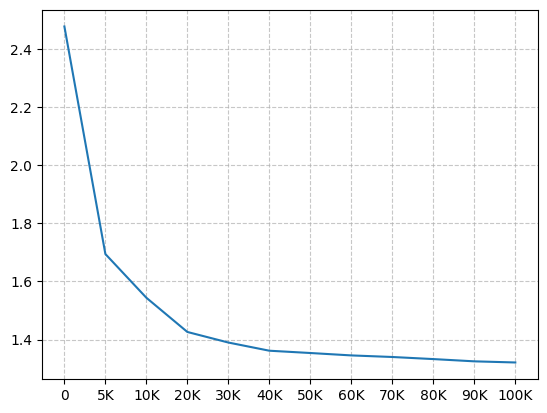

In [8]:
from matplotlib import pyplot as plt

x = list(dict_scores.keys())
y = [val for val in dict_scores.values()]
x = [0]+x
y = [[old_score,0]] + y

plt.plot(x, [val[0] for val in y])

# Calculate percentage drop between adjacent values
# percentage_drops = [(y[i][0] - y[i+1][0])/(y[i+1][1] - y[i][1]) for i in range(len(y)-1)]

# # Create a new figure for percentage drops
# plt.plot(x[1:], percentage_drops)
# plt.title('Percentage Drop in Score Between Adjacent Vocabulary Sizes')
# plt.xlabel('Vocabulary Size')
# plt.ylabel('Percentage Drop (%)')
# plt.xticks(rotation=45)
plt.grid(linestyle='--', alpha=0.7)
# plt.tight_layout()

In [ ]:
y

In [ ]:
idx = 0
gain_in_fragments = []
tokenizer = AutoTokenizer.from_pretrained("./BioASQ-FromScratch-Llama3_Vocab/BioASQ_10K_1.0_")
import numpy as np
with open('../../../../../TxtInputFiles/CPT_input.txt') as f:
    for line in f:
        try:
            line = line.strip()
            org_enc = tokenizer_base.encode(line)
            vocab_enc = tokenizer.encode(line)
            
            org_dec = tokenizer_base.decode(org_enc)
            vocab_dec = tokenizer.decode(vocab_enc)
            
            assert org_dec == vocab_dec, f'Failed at {idx}'
            
            gain_in_fragments.append((len(org_enc)-len(vocab_enc))/len(org_enc))
            
            idx += 1
            if idx%1000 == 0:
                print(f'Processed {idx}.... {np.percentile(gain_in_fragments, [0,10,50,90,100])}')
        except:
            print(f'--------------------Failed at {idx}--------------------')
            print(f'Orig : {org_dec}')
            print(f'Vocab: {vocab_dec}')
    

In [ ]:
np.percentile(gain_in_fragments, [0,10,50,90,100])